In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from cohorts.cohort_performance import plot_weekly_cohorts_performance_trend__single_quoters, get_journey
from cohorts.cohort_performance import plot_weekly_cohorts_performance_trend__switchers
from cohorts.cohort_performance import plot_quarters_report, plot_intra_quarters, plot_quarter_x_product_report


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('pipeline_data/cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

print(df_clean.shape)
# print(df_clean.dtypes)
# print(df_clean.head(3).to_string())

Loaded data: 37,008 quotes from 25,716 customers
(37008, 50)


In [2]:
print(df_clean['statut_devis'].value_counts())

statut_devis
Expiré                                       13689
Validé, signé, réalisé et conforme           10088
Refusé                                        5000
En attente de retour client                   3537
Autre devis de la société retenu              2661
Validé, signé - en attente d'intervention      878
En cours                                       672
Validé,signé mais abandonné                    414
En attente de retour agence                     69
Name: count, dtype: int64


In [3]:
# 1. Check customers who converted more than once
multi_converted = df_clean.groupby('numero_compte')['fg_devis_accepte'].sum()
print("Conversions per customer distribution:")
print(multi_converted.value_counts().sort_index().head(10))
print(f"\nCustomers with >1 conversion: {(multi_converted > 1).sum()}")
print(f"Total customers: {df_clean['numero_compte'].nunique():,}")

# 2. Check quote creation date range
print(f"\nQuote date range: {df_clean['dt_creation_devis'].min()} → {df_clean['dt_creation_devis'].max()}")

# 3. Check how long open quotes stay open (time between creation and last activity)
not_converted = df_clean[df_clean['fg_devis_accepte'] == 0].copy()
not_converted['days_since_creation'] = (pd.Timestamp('2026-03-31') - not_converted['dt_creation_devis']).dt.days
print("\nDays since creation for non-converted quotes:")
print(not_converted['days_since_creation'].describe())
print("\nPercentile distribution:")
for p in [25, 50, 60, 75, 90, 95]:
    print(f"  {p}th percentile: {not_converted['days_since_creation'].quantile(p/100):.0f} days")

Conversions per customer distribution:
fg_devis_accepte
0.0    15577
1.0     9449
2.0      591
3.0       73
4.0       19
5.0        4
6.0        1
7.0        2
Name: count, dtype: int64

Customers with >1 conversion: 690
Total customers: 25,716

Quote date range: 2023-01-02 00:00:00 → 2026-03-25 00:00:00

Days since creation for non-converted quotes:
count    26042.000000
mean       467.985831
std        313.961461
min          6.000000
25%        191.000000
50%        427.000000
75%        706.000000
max       1184.000000
Name: days_since_creation, dtype: float64

Percentile distribution:
  25th percentile: 191 days
  50th percentile: 427 days
  60th percentile: 524 days
  75th percentile: 706 days
  90th percentile: 922 days
  95th percentile: 1040 days


In [4]:
# Quotes per non-converted customer
non_conv = df_clean[df_clean['numero_compte'].isin(
    df_clean.groupby('numero_compte')['fg_devis_accepte']
    .max()[lambda x: x == 0].index
)]

quotes_per_customer = non_conv.groupby('numero_compte')['id_devis'].count()
print("Quotes per non-converted customer:")
print(quotes_per_customer.value_counts().sort_index().head(10))
print(f"\nSingle-quoters: {(quotes_per_customer == 1).sum():,}")
print(f"Multi-quoters:  {(quotes_per_customer > 1).sum():,}")
print(f"% multi:        {(quotes_per_customer > 1).mean():.1%}")

Quotes per non-converted customer:
id_devis
1     11247
2      3309
3       693
4       232
5        54
6        22
7         5
8         7
9         3
10        2
Name: count, dtype: int64

Single-quoters: 11,247
Multi-quoters:  4,330
% multi:        27.8%


In [5]:
# For non-converted customers, when was their first quote?
first_quotes = non_conv.groupby('numero_compte')['dt_creation_devis'].min()

print("First quote date distribution for non-converted customers:")
print(first_quotes.dt.year.value_counts().sort_index())
print()
print(first_quotes.dt.to_period('Q').value_counts().sort_index())

First quote date distribution for non-converted customers:
dt_creation_devis
2023    2784
2024    4842
2025    6187
2026    1764
Name: count, dtype: int64

dt_creation_devis
2023Q1     547
2023Q2     545
2023Q3     621
2023Q4    1071
2024Q1    1030
2024Q2    1083
2024Q3    1183
2024Q4    1546
2025Q1    1511
2025Q2    1304
2025Q3    1540
2025Q4    1832
2026Q1    1764
Freq: Q-DEC, Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Snapshot dates: end of each quarter ───────────────────────────────────────
snapshots = pd.date_range('2024-03-31', '2026-03-31', freq='Q')
snapshots = snapshots.append(pd.DatetimeIndex(['2026-03-31']))
snapshots = snapshots.unique()
print("Snapshot dates:", snapshots.strftime('%Y-%m-%d').tolist())

# ── Product mapping ───────────────────────────────────────────────────────────
def map_product(val):
    if pd.isna(val):
        return 'Other'
    v = str(val).upper()
    if 'HEAT_PUMP' in v:   return 'HP'
    if 'BOILER_GAS' in v:  return 'Boiler'
    if 'AIR_CONDITIONER' in v: return 'AC'
    if 'STOVE' in v:       return 'Stove'
    return 'Other'

df_clean['product'] = df_clean['regroup_famille_equipement_produit_principal'].map(map_product)

# ── Build pipeline snapshot at each quarter-end ───────────────────────────────
records = []

for snap_date in snapshots:
    # Quotes created on or before snapshot date
    snap_quotes = df_clean[df_clean['dt_creation_devis'] <= snap_date].copy()

    # Non-converted customers at snapshot date
    converted_by_snap = (
        snap_quotes.groupby('numero_compte')['fg_devis_accepte']
        .max()
    )
    non_conv_customers = converted_by_snap[converted_by_snap == 0].index

    # Filter to non-converted customers' quotes
    open_quotes = snap_quotes[snap_quotes['numero_compte'].isin(non_conv_customers)]

    # Per customer: first product, last product, quote count
    customer_snap = open_quotes.groupby('numero_compte').agg(
        first_product=('product', 'first'),
        last_product=('product',  'last'),
        n_quotes=('id_devis',     'count')
    ).reset_index()

    customer_snap['segment']      = customer_snap['first_product'] + ' → ' + customer_snap['last_product']
    customer_snap['quoter_type']  = customer_snap['n_quotes'].apply(
        lambda x: 'Single-quoter' if x == 1 else 'Multi-quoter'
    )
    customer_snap['snapshot']     = snap_date
    customer_snap['snap_label']   = snap_date.strftime('%Y Q') + str((snap_date.month - 1) // 3 + 1)

    records.append(customer_snap)

pipeline = pd.concat(records, ignore_index=True)
print(f"\nTotal pipeline records: {len(pipeline):,}")
print(pipeline['segment'].value_counts().head(10))

ValueError: Invalid frequency: Q. Failed to parse with error message: ValueError("'Q' is no longer supported for offsets. Please use 'QE' instead.")

In [7]:
# ── Aggregate counts per snapshot × segment × quoter_type ────────────────────
main_diag = ['Boiler → Boiler', 'Stove → Stove', 'AC → AC', 'HP → HP']
top_switch = ['Other → HP', 'Boiler → HP', 'HP → Stove', 'AC → HP', 'HP → Boiler']

seg_colors = {
    'Boiler → Boiler': 'steelblue',
    'Stove → Stove':   'tomato',
    'AC → AC':         'mediumseagreen',
    'HP → HP':         'darkorange',
    'Other → HP':      'purple',
    'Boiler → HP':     'brown',
    'HP → Stove':      'pink',
    'AC → HP':         'olive',
    'HP → Boiler':     'grey'
}

agg = (
    pipeline.groupby(['snap_label', 'segment', 'quoter_type'])
    .size()
    .reset_index(name='n_customers')
)

snap_labels = pipeline.sort_values('snapshot')['snap_label'].unique()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Quote Pipeline Backlog — End of Quarter Snapshots',
             fontsize=14, fontweight='bold')

titles = [
    ('Single-quoter — Diagonal',  'Single-quoter', main_diag),
    ('Multi-quoter — Diagonal',   'Multi-quoter',  main_diag),
    ('Single-quoter — Switchers', 'Single-quoter', top_switch),
    ('Multi-quoter — Switchers',  'Multi-quoter',  top_switch),
]

for ax, (title, qtype, segs) in zip(axes.flatten(), titles):
    for seg in segs:
        d = agg[
            (agg['quoter_type'] == qtype) &
            (agg['segment']     == seg)
        ].set_index('snap_label').reindex(snap_labels)

        if d['n_customers'].isna().all():
            continue

        ax.plot(snap_labels, d['n_customers'].values,
                marker='o', linewidth=2.2, markersize=6,
                color=seg_colors.get(seg, 'black'),
                label=seg)

    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Customers in pipeline')
    ax.set_xlabel('Quarter end')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

    # Shade 2026 Q1
    ax.axvspan(7.5, 8.5, alpha=0.08, color='orange')
    ax.text(7.6, ax.get_ylim()[1] * 0.97, '⚠ partial',
            fontsize=7.5, color='darkorange', va='top')

plt.tight_layout()
plt.savefig('pipeline_backlog.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'pipeline' is not defined

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Snapshot dates: end of each quarter ───────────────────────────────────────
snapshots = pd.date_range('2024-03-31', '2026-03-31', freq='QE')
snapshots = snapshots.append(pd.DatetimeIndex(['2026-03-31']))
snapshots = snapshots.unique()
print("Snapshot dates:", snapshots.strftime('%Y-%m-%d').tolist())

# ── Product mapping ───────────────────────────────────────────────────────────
def map_product(val):
    if pd.isna(val):
        return 'Other'
    v = str(val).upper()
    if 'HEAT_PUMP' in v:   return 'HP'
    if 'BOILER_GAS' in v:  return 'Boiler'
    if 'AIR_CONDITIONER' in v: return 'AC'
    if 'STOVE' in v:       return 'Stove'
    return 'Other'

df_clean['product'] = df_clean['regroup_famille_equipement_produit_principal'].map(map_product)

# ── Build pipeline snapshot at each quarter-end ───────────────────────────────
records = []

for snap_date in snapshots:
    # Quotes created on or before snapshot date
    snap_quotes = df_clean[df_clean['dt_creation_devis'] <= snap_date].copy()

    # Non-converted customers at snapshot date
    converted_by_snap = (
        snap_quotes.groupby('numero_compte')['fg_devis_accepte']
        .max()
    )
    non_conv_customers = converted_by_snap[converted_by_snap == 0].index

    # Filter to non-converted customers' quotes
    open_quotes = snap_quotes[snap_quotes['numero_compte'].isin(non_conv_customers)]

    # Per customer: first product, last product, quote count
    customer_snap = open_quotes.groupby('numero_compte').agg(
        first_product=('product', 'first'),
        last_product=('product',  'last'),
        n_quotes=('id_devis',     'count')
    ).reset_index()

    customer_snap['segment']      = customer_snap['first_product'] + ' → ' + customer_snap['last_product']
    customer_snap['quoter_type']  = customer_snap['n_quotes'].apply(
        lambda x: 'Single-quoter' if x == 1 else 'Multi-quoter'
    )
    customer_snap['snapshot']     = snap_date
    customer_snap['snap_label']   = snap_date.strftime('%Y Q') + str((snap_date.month - 1) // 3 + 1)

    records.append(customer_snap)

pipeline = pd.concat(records, ignore_index=True)
print(f"\nTotal pipeline records: {len(pipeline):,}")
print(pipeline['segment'].value_counts().head(10))

Snapshot dates: ['2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31', '2026-03-31']

Total pipeline records: 84,719
segment
Boiler → Boiler    20242
Stove → Stove      18708
AC → AC            17465
HP → HP            13987
Other → Other       7525
Other → HP          1093
Boiler → HP          793
HP → Stove           646
AC → HP              560
Other → Stove        549
Name: count, dtype: int64


NameError: name 'snap_labels' is not defined

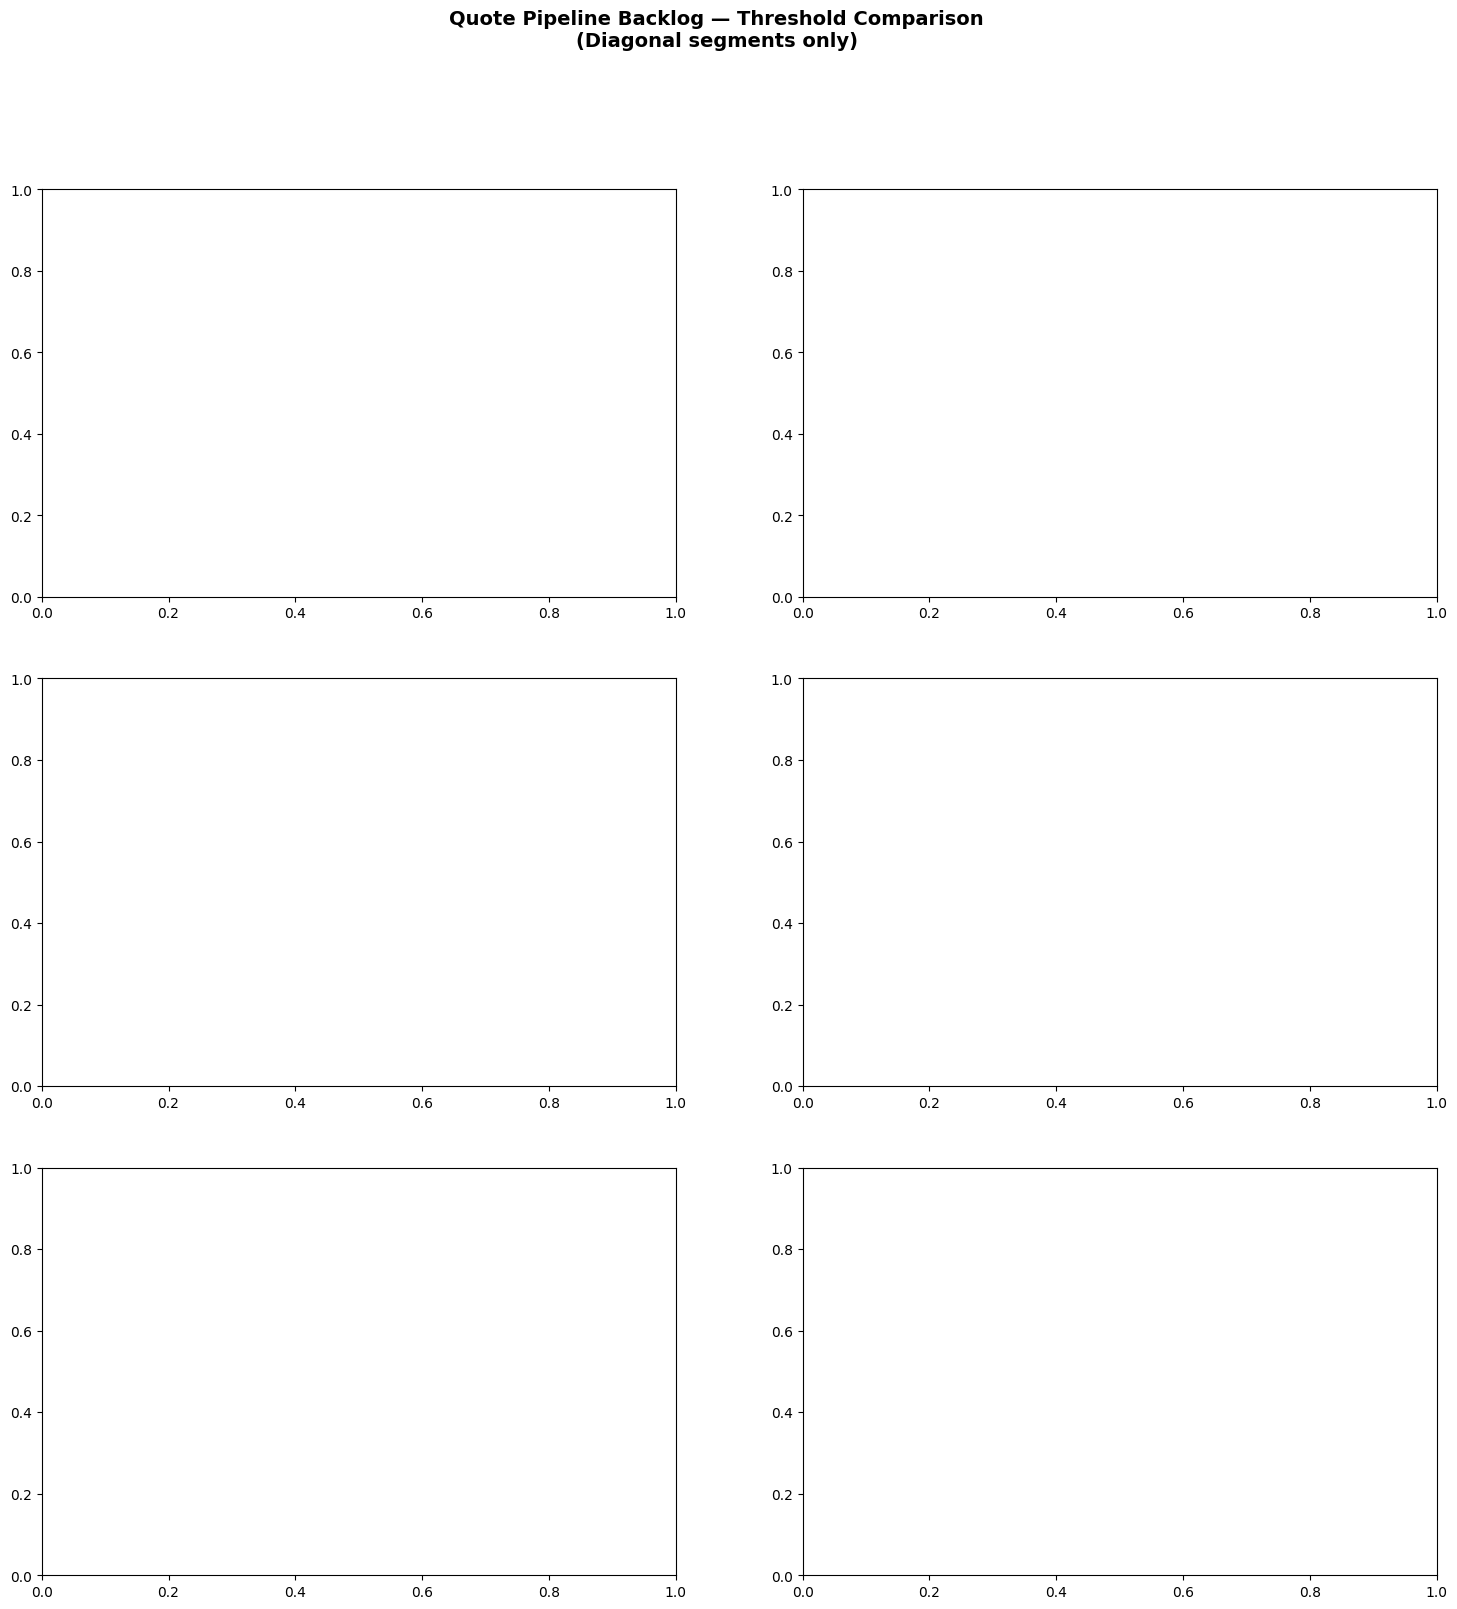

In [9]:
thresholds = {
    'No threshold':   None,
    '12-month window': 365,
    '60-day window':   60
}

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Quote Pipeline Backlog — Threshold Comparison\n(Diagonal segments only)',
             fontsize=14, fontweight='bold')

for row, (thresh_label, days) in enumerate(thresholds.items()):
    for col, qtype in enumerate(['Single-quoter', 'Multi-quoter']):
        ax = axes[row, col]

        for snap_date, snap_label in zip(snapshots, snap_labels):
            pass  # rebuilt below

        # Rebuild pipeline with threshold applied
        thresh_records = []
        for snap_date in snapshots:
            snap_quotes = df_clean[df_clean['dt_creation_devis'] <= snap_date].copy()

            # Apply threshold — filter to quotes created within window
            if days is not None:
                snap_quotes = snap_quotes[
                    snap_quotes['dt_creation_devis'] >= snap_date - pd.Timedelta(days=days)
                ]

            # Non-converted at snapshot
            converted_by_snap = snap_quotes.groupby('numero_compte')['fg_devis_accepte'].max()
            non_conv = converted_by_snap[converted_by_snap == 0].index

            # All quotes for those customers up to snapshot (not just in window)
            # to correctly determine first→last product journey
            all_quotes_to_snap = df_clean[
                (df_clean['dt_creation_devis'] <= snap_date) &
                (df_clean['numero_compte'].isin(non_conv))
            ]

            customer_snap = all_quotes_to_snap.groupby('numero_compte').agg(
                first_product=('product', 'first'),
                last_product=('product',  'last'),
                n_quotes=('id_devis',     'count')
            ).reset_index()

            customer_snap['segment']     = customer_snap['first_product'] + ' → ' + customer_snap['last_product']
            customer_snap['quoter_type'] = customer_snap['n_quotes'].apply(
                lambda x: 'Single-quoter' if x == 1 else 'Multi-quoter'
            )
            customer_snap['snapshot']    = snap_date
            customer_snap['snap_label']  = snap_date.strftime('%Y Q') + str((snap_date.month - 1) // 3 + 1)
            thresh_records.append(customer_snap)

        thresh_pipeline = pd.concat(thresh_records, ignore_index=True)

        thresh_agg = (
            thresh_pipeline.groupby(['snap_label', 'segment', 'quoter_type'])
            .size()
            .reset_index(name='n_customers')
        )

        for seg in main_diag:
            d = thresh_agg[
                (thresh_agg['quoter_type'] == qtype) &
                (thresh_agg['segment']     == seg)
            ].set_index('snap_label').reindex(snap_labels)

            if d['n_customers'].isna().all():
                continue

            ax.plot(snap_labels, d['n_customers'].values,
                    marker='o', linewidth=2.2, markersize=6,
                    color=seg_colors.get(seg, 'black'),
                    label=seg)

        ax.set_title(f'{thresh_label} — {qtype}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Customers in pipeline')
        ax.set_xlabel('Quarter end')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)
        ax.axvspan(7.5, 8.5, alpha=0.08, color='orange')
        ax.text(7.6, ax.get_ylim()[1] * 0.97, '⚠ partial',
                fontsize=7.5, color='darkorange', va='top')

plt.tight_layout()
plt.savefig('pipeline_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()